# Regression Models Lab Notebook
This notebook is written in a simple step-by-step way.

## Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder, PolynomialFeatures
from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [2]:
# Load the csv file
path = '/Users/hare/Desktop/bmw_global_sales_dataset.csv'
data = pd.read_csv(path)
data.head()

,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold
0,2021,1,Australia,X1,SUV,Petrol,82234,315372,96,0.97,6.29,1.2,8,324
1,2018,8,Australia,i4,Sedan,Electric,82291,447798,234,0.97,6.29,1.2,7,556
2,2022,12,USA,5 Series,Electric,Hybrid,40594,259755,25,0.97,6.29,1.2,7,152
3,2019,11,Australia,i7,SUV,Electric,42371,323541,319,0.97,6.29,1.2,5,730
4,2021,12,Brazil,X5,SUV,Diesel,82315,482015,367,0.97,6.29,1.2,2,1156


In [3]:
# Basic dataset info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   1000 non-null   int64  
 1   month                  1000 non-null   int64  
 2   country                1000 non-null   object 
 3   model                  1000 non-null   object 
 4   segment                1000 non-null   object 
 5   engine_type            1000 non-null   object 
 6   price_usd              1000 non-null   int64  
 7   marketing_spend_usd    1000 non-null   int64  
 8   dealership_count       1000 non-null   int64  
 9   fuel_price_usd         1000 non-null   float64
 10  gdp_growth_percent     1000 non-null   float64
 11  interest_rate_percent  1000 non-null   float64
 12  competition_index      1000 non-null   int64  
 13  units_sold             1000 non-null   int64  
dtypes: float64(3), int64(7), object(4)
memory usage: 109.5+ K

In [4]:
# Statistical summary
data.describe(include='all')

,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold
count,1000.000000,1000.000000,1000,1000,1000,1000,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1000.000000
unique,NaN,NaN,10,10,3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,China,3 Series,Electric,Electric,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,112,115,341,266,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2019.448000,6.487000,NaN,NaN,NaN,NaN,76535.747000,279492.230000,200.230000,9.700000e-01,6.290000e+00,1.200000e+00,5.572000,633.192000
std,2.912005,3.510863,NaN,NaN,NaN,NaN,25360.933749,127010.559722,113.096127,2.221557e-16,1.777246e-15,4.443114e-16,2.944059,263.346628
min,2015.000000,1.000000,NaN,NaN,NaN,NaN,35060.000000,50363.000000,10.000000,9.700000e-01,6.290000e+00,1.200000e+00,1.000000,15.000000
25%,2017.000000,3.000000,NaN,NaN,NaN,NaN,54578.750000,173552.250000,101.750000,9.700000e-01,6.290000e+00,1.200000e+00,3.000000,432.750000
50%,2019.000000,7.000000,NaN,NaN,NaN,NaN,75726.000000,278733.500000,197.000000,9.700000e-01,6.290000e+00,1.200000e+00,6.000000,630.000000
75%,2022.000000,10.000000,NaN,NaN,NaN,NaN,98730.250000,390110.000000,297.000000,9.700000e-01,6.290000e+00,1.200000e+00,8.000000,842.500000


## Data Cleaning

In [5]:
# Keep only numerical columns
num_data = data.select_dtypes(include=[np.number]).copy()

# Fill missing values using mean
imputer = SimpleImputer(strategy='mean')
num_data[num_data.columns] = imputer.fit_transform(num_data)

print('Final shape:', num_data.shape)
print('Numerical columns:', list(num_data.columns))

Final shape: (1000, 10)
Numerical columns: ['year', 'month', 'price_usd', 'marketing_spend_usd', 'dealership_count', 'fuel_price_usd', 'gdp_growth_percent', 'interest_rate_percent', 'competition_index', 'units_sold']


## Visualization

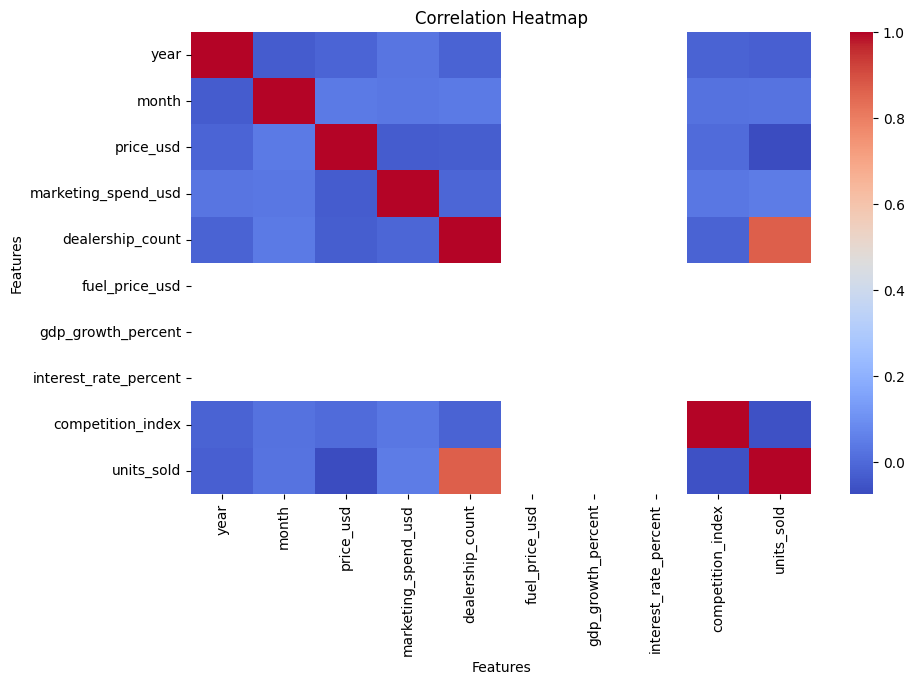

In [6]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(num_data.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

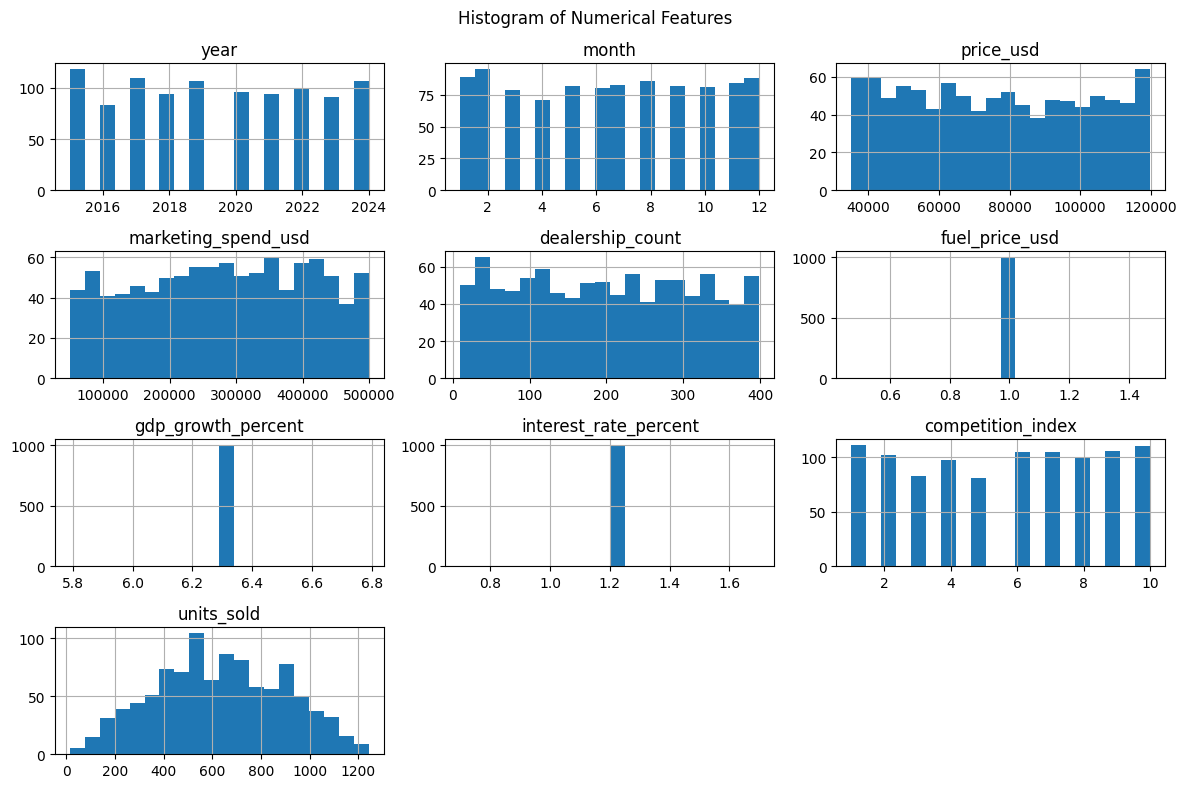

In [7]:
# Histogram for all numeric columns
num_data.hist(figsize=(12, 8), bins=20)
plt.suptitle('Histogram of Numerical Features')
plt.tight_layout()
plt.show()

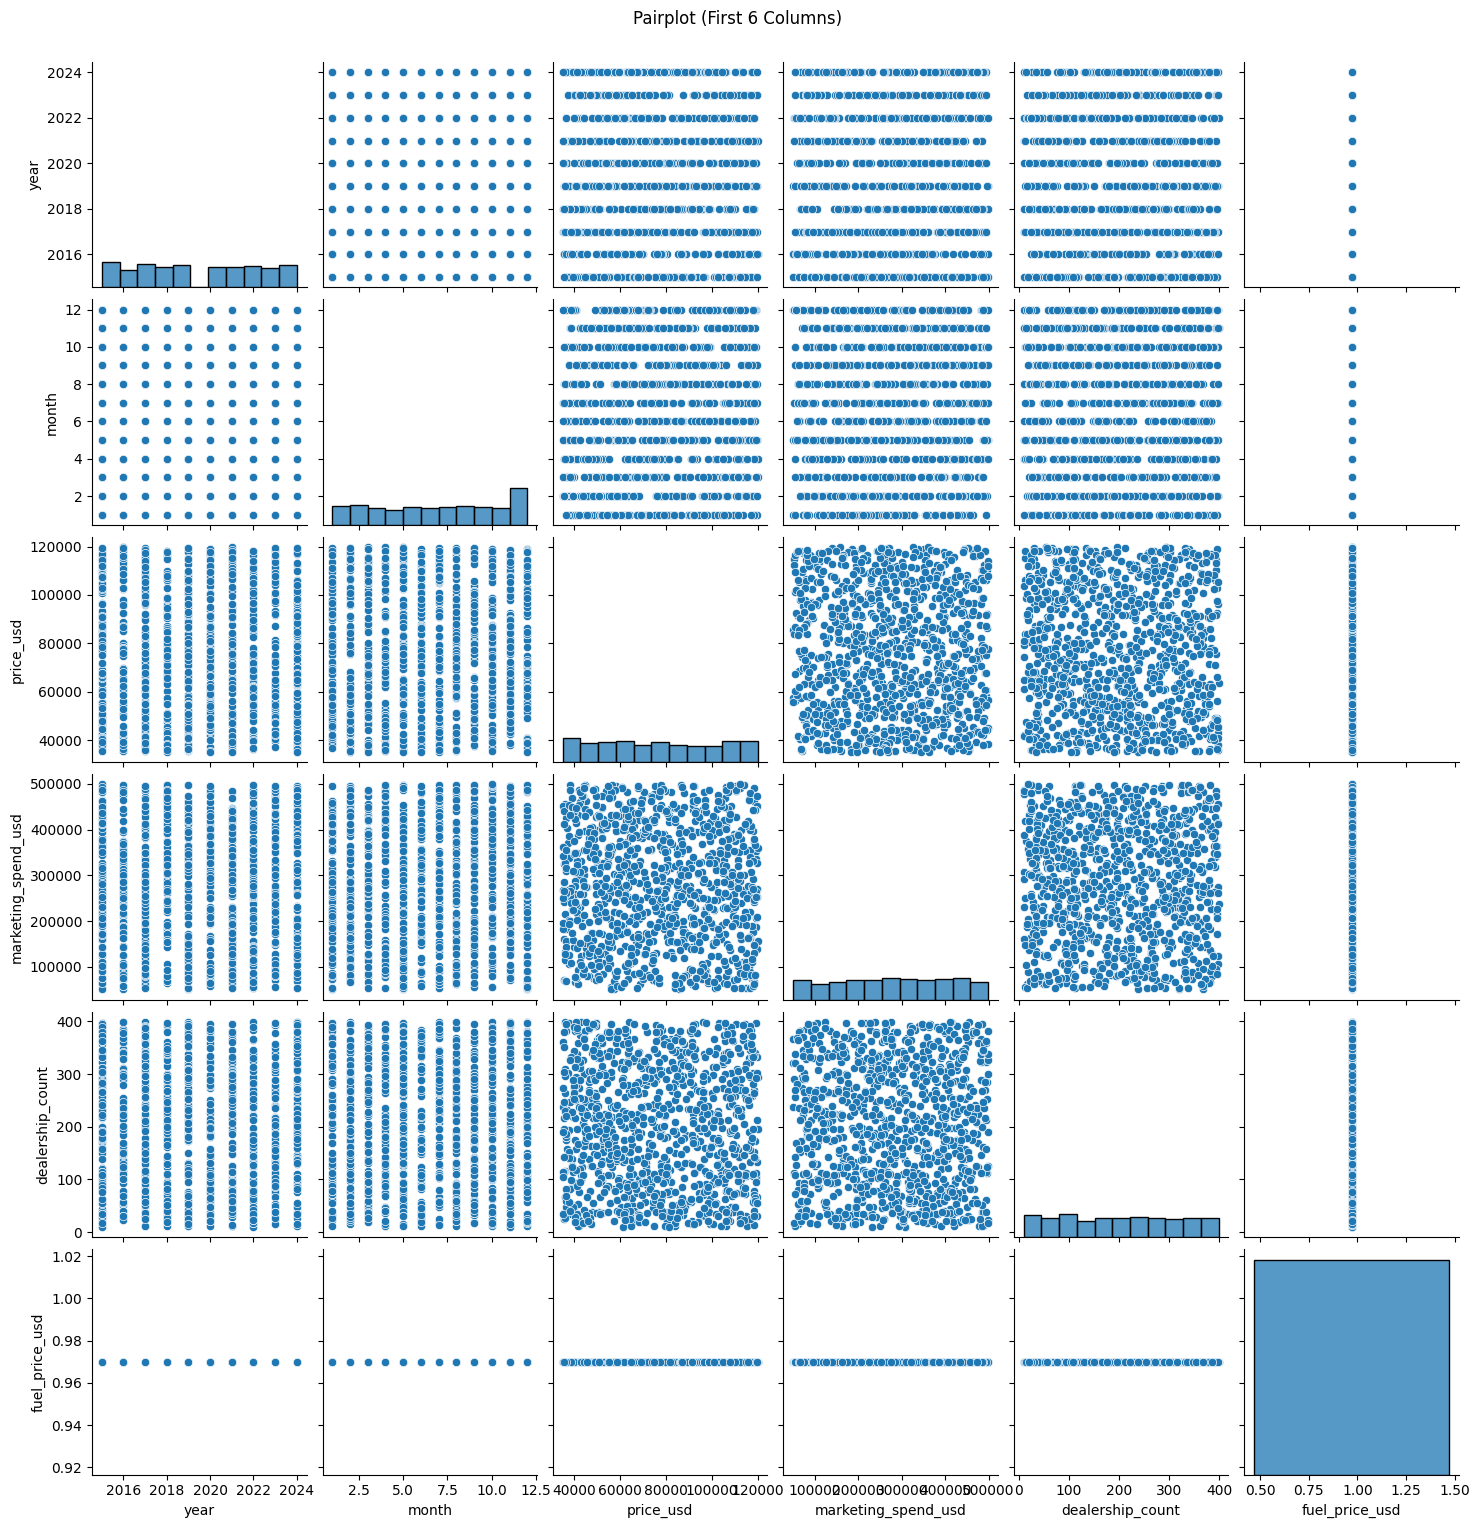

In [8]:
# Pairplot (if too many columns, use first 6)
if num_data.shape[1] <= 6:
    sns.pairplot(num_data)
    plt.suptitle('Pairplot', y=1.02)
    plt.show()
else:
    small_data = num_data.iloc[:, :6]
    sns.pairplot(small_data)
    plt.suptitle('Pairplot (First 6 Columns)', y=1.02)
    plt.show()

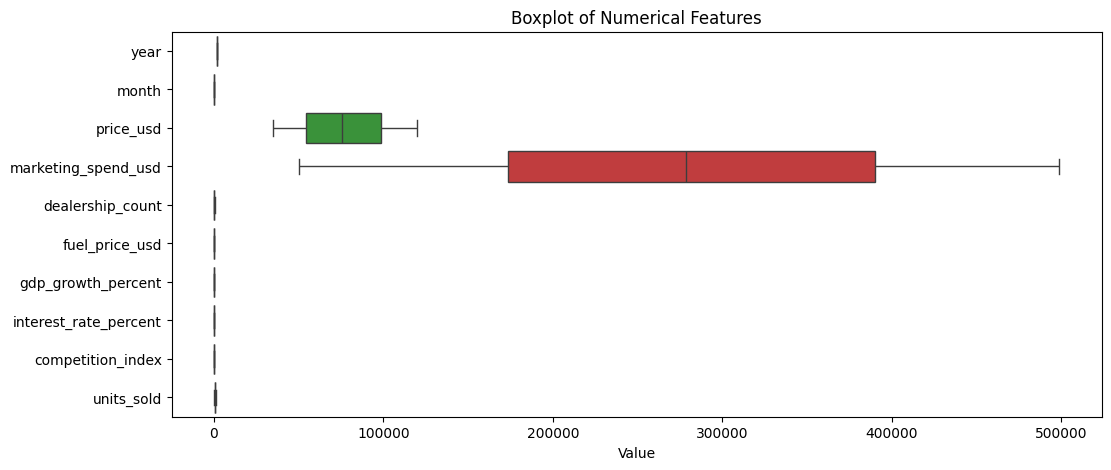

In [9]:
# Boxplot for outliers
plt.figure(figsize=(12, 5))
sns.boxplot(data=num_data, orient='h')
plt.title('Boxplot of Numerical Features')
plt.xlabel('Value')
plt.show()

## Feature and Target Selection

In [10]:
# Last numeric column is target
X = num_data.iloc[:, :-1]
y = num_data.iloc[:, -1]

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Target column:', num_data.columns[-1])

X shape: (1000, 9)
y shape: (1000,)
Target column: units_sold


## Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (800, 9)
Test size: (200, 9)


## Model Training, Prediction, Evaluation

### 1. Linear Regression

Linear Regression MSE: 16260.049658133685
First 5 predictions: [337.96497521 642.19500771 986.8091967  889.53379929 491.41746151]


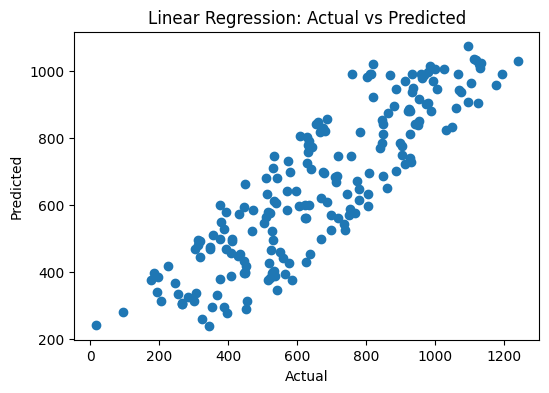

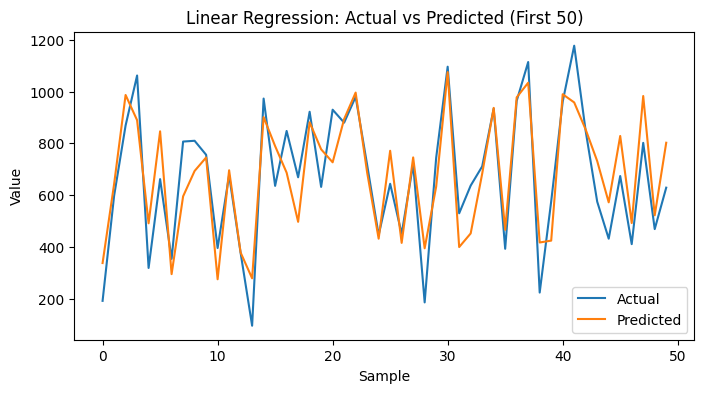

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)

print('Linear Regression MSE:', mse_lr)
print('First 5 predictions:', y_pred_lr[:5])

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_lr)
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred_lr[:50], label='Predicted')
plt.title('Linear Regression: Actual vs Predicted (First 50)')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.legend()
plt.show()

### 2. Polynomial Regression (Degree 2)

Polynomial Regression MSE: 17093.66296432987
First 5 predictions: [ 329.756004    629.89078122 1014.36108334  895.20381214  490.52634812]


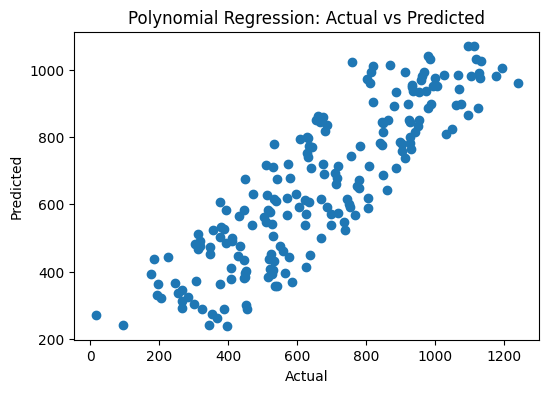

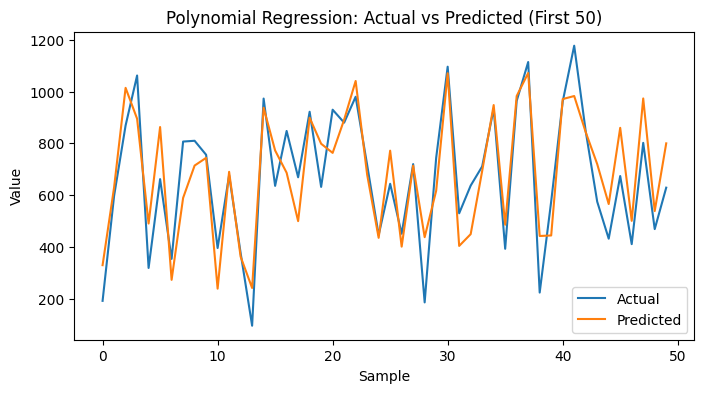

In [13]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)

print('Polynomial Regression MSE:', mse_poly)
print('First 5 predictions:', y_pred_poly[:5])

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_poly)
plt.title('Polynomial Regression: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred_poly[:50], label='Predicted')
plt.title('Polynomial Regression: Actual vs Predicted (First 50)')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.legend()
plt.show()

### 3. Stepwise Regression (Sequential Feature Selector)

Stepwise Regression MSE: 16187.328128724914
First 5 predictions: [336.59228827 649.63598884 986.6743622  887.05623906 497.47175838]


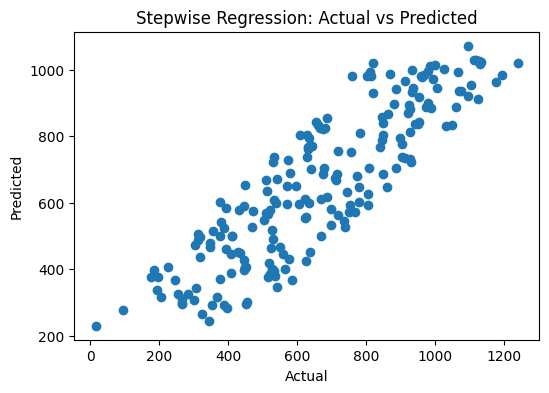

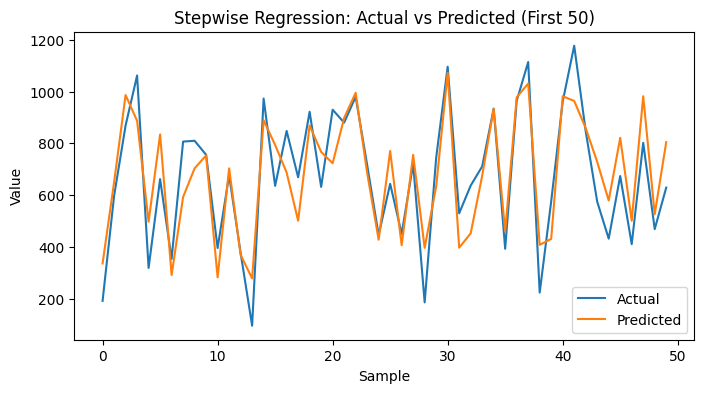

In [14]:
base_model = LinearRegression()
sfs = SequentialFeatureSelector(base_model, n_features_to_select='auto', direction='forward')
sfs.fit(X_train, y_train)

X_train_sfs = sfs.transform(X_train)
X_test_sfs = sfs.transform(X_test)

step_model = LinearRegression()
step_model.fit(X_train_sfs, y_train)
y_pred_step = step_model.predict(X_test_sfs)
mse_step = mean_squared_error(y_test, y_pred_step)

print('Stepwise Regression MSE:', mse_step)
print('First 5 predictions:', y_pred_step[:5])

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_step)
plt.title('Stepwise Regression: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred_step[:50], label='Predicted')
plt.title('Stepwise Regression: Actual vs Predicted (First 50)')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.legend()
plt.show()

### 4. Decision Tree Regression

Decision Tree MSE: 34938.29
First 5 predictions: [477. 495. 749. 737. 309.]


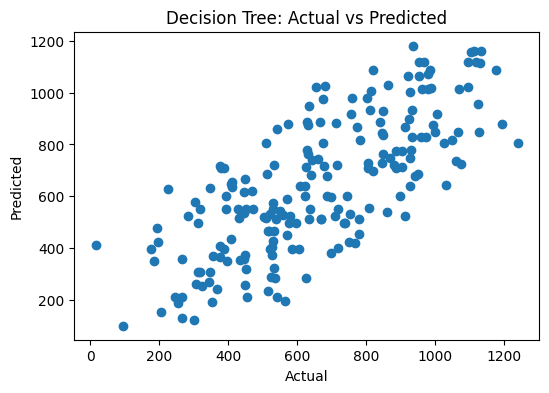

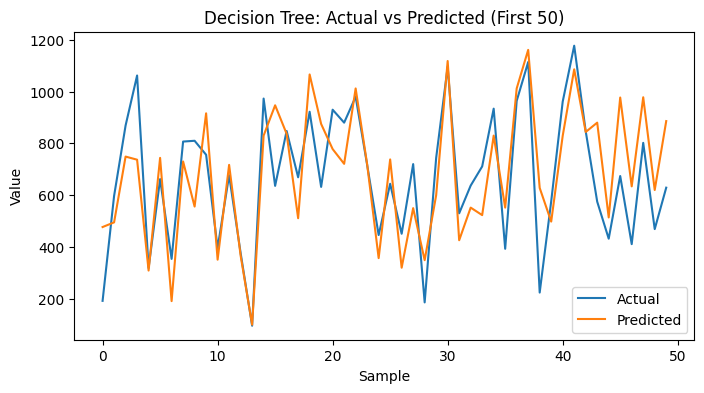

In [15]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)

print('Decision Tree MSE:', mse_dt)
print('First 5 predictions:', y_pred_dt[:5])

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_dt)
plt.title('Decision Tree: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred_dt[:50], label='Predicted')
plt.title('Decision Tree: Actual vs Predicted (First 50)')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.legend()
plt.show()

### 5. Random Forest Regression

Random Forest MSE: 18288.8948265
First 5 predictions: [432.63 578.96 944.92 927.44 489.52]


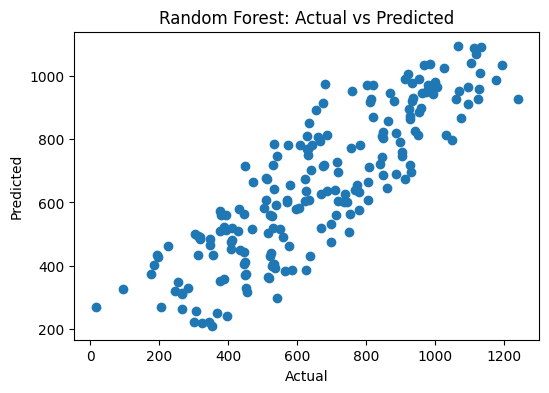

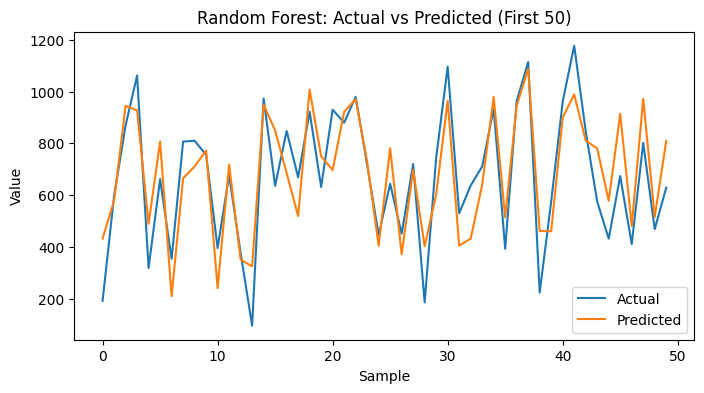

In [16]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print('Random Forest MSE:', mse_rf)
print('First 5 predictions:', y_pred_rf[:5])

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_rf)
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred_rf[:50], label='Predicted')
plt.title('Random Forest: Actual vs Predicted (First 50)')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.legend()
plt.show()

### 6. Support Vector Regression

Support Vector Regression MSE: 69872.163058935
First 5 predictions: [622.60924076 624.84522712 622.57541874 625.06726617 623.65211931]


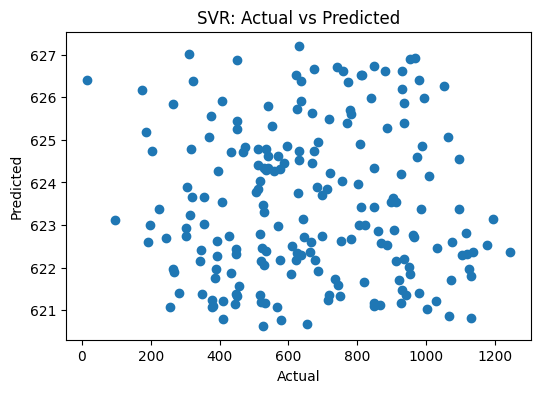

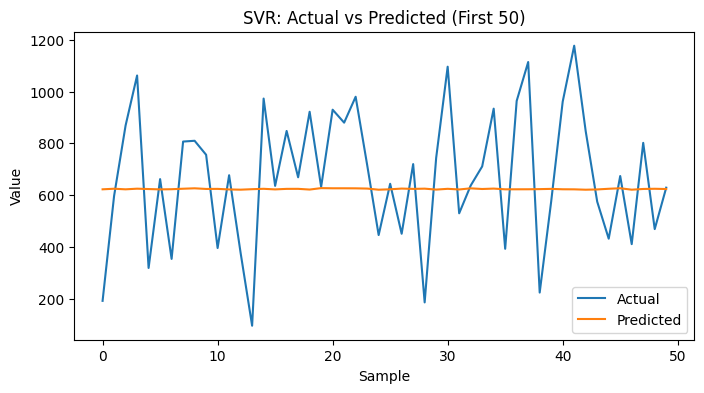

In [17]:
svr = SVR()
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)
mse_svr = mean_squared_error(y_test, y_pred_svr)

print('Support Vector Regression MSE:', mse_svr)
print('First 5 predictions:', y_pred_svr[:5])

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_svr)
plt.title('SVR: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred_svr[:50], label='Predicted')
plt.title('SVR: Actual vs Predicted (First 50)')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.legend()
plt.show()

### 7. Ridge Regression

Ridge Regression MSE: 16260.031885287486
First 5 predictions: [337.96263344 642.19577266 986.81174478 889.53319465 491.42093627]


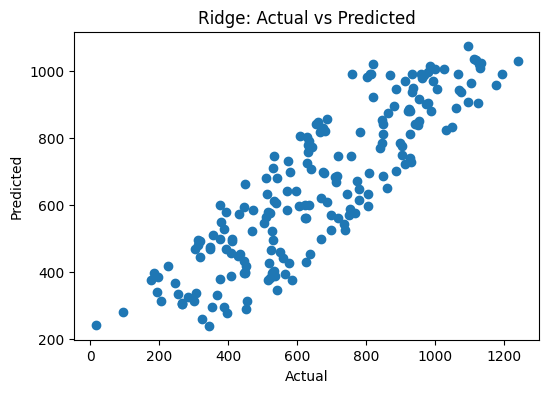

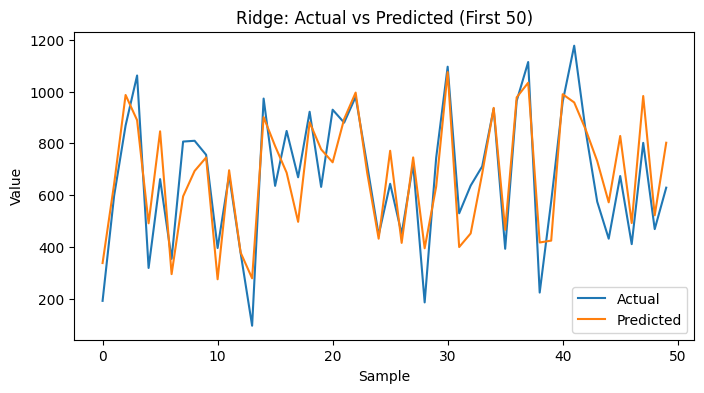

In [18]:
ridge = Ridge()
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print('Ridge Regression MSE:', mse_ridge)
print('First 5 predictions:', y_pred_ridge[:5])

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_ridge)
plt.title('Ridge: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred_ridge[:50], label='Predicted')
plt.title('Ridge: Actual vs Predicted (First 50)')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.legend()
plt.show()

### 8. Lasso Regression

Lasso Regression MSE: 16256.56410112473
First 5 predictions: [337.46648341 642.7559141  987.59372946 889.12737729 492.13299403]


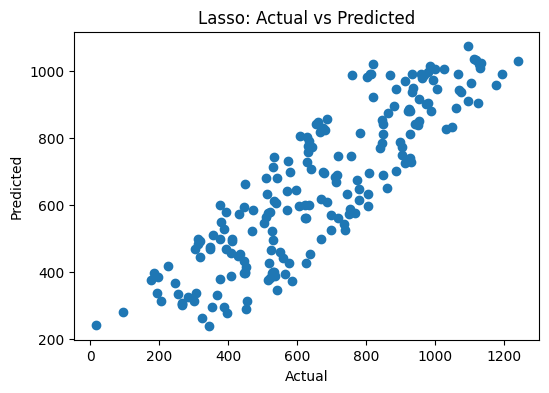

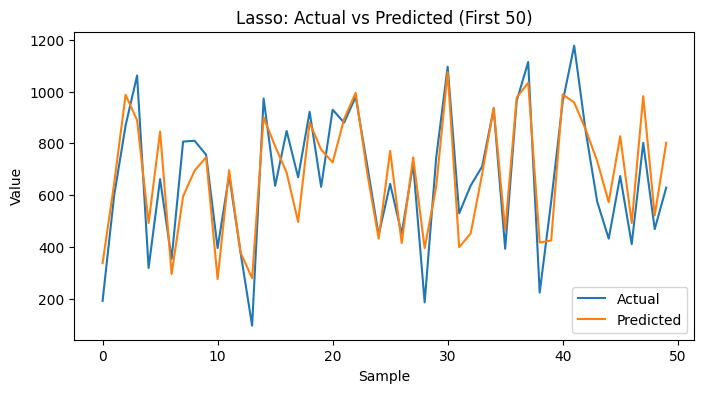

In [19]:
lasso = Lasso()
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

print('Lasso Regression MSE:', mse_lasso)
print('First 5 predictions:', y_pred_lasso[:5])

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_lasso)
plt.title('Lasso: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred_lasso[:50], label='Predicted')
plt.title('Lasso: Actual vs Predicted (First 50)')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.legend()
plt.show()

### 9. ElasticNet Regression

ElasticNet Regression MSE: 16252.506627699258
First 5 predictions: [336.8451615  642.75160945 988.14628021 889.10936847 493.06718546]


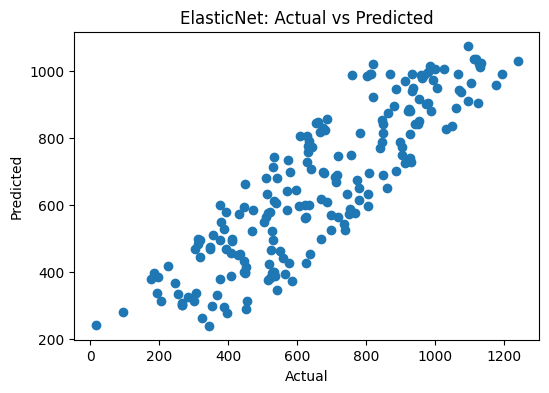

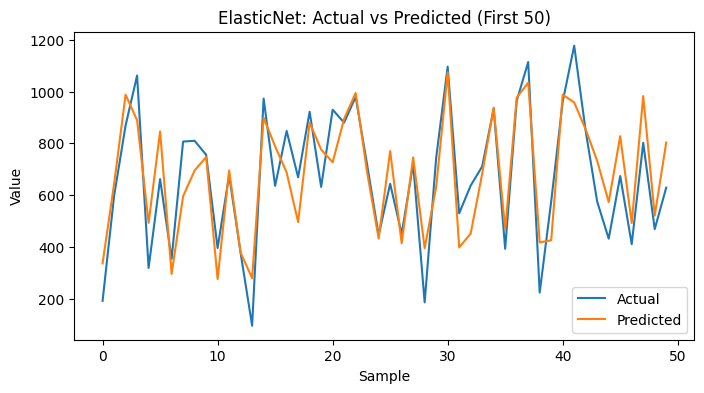

In [20]:
elastic = ElasticNet()
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)

print('ElasticNet Regression MSE:', mse_elastic)
print('First 5 predictions:', y_pred_elastic[:5])

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_elastic)
plt.title('ElasticNet: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred_elastic[:50], label='Predicted')
plt.title('ElasticNet: Actual vs Predicted (First 50)')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.legend()
plt.show()

### 10. Bayesian Linear Regression

Bayesian Linear Regression MSE: 16249.342645911123
First 5 predictions: [328.87993572 645.28892284 996.83049615 886.89950002 505.13206155]


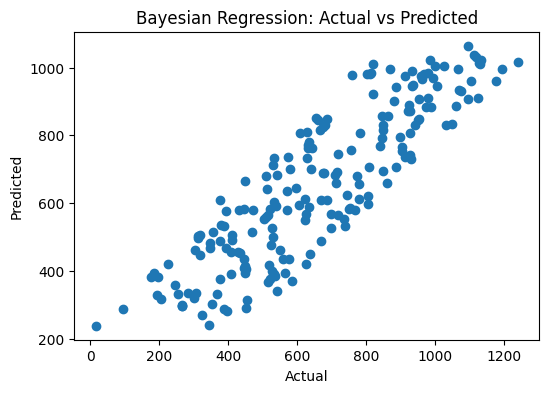

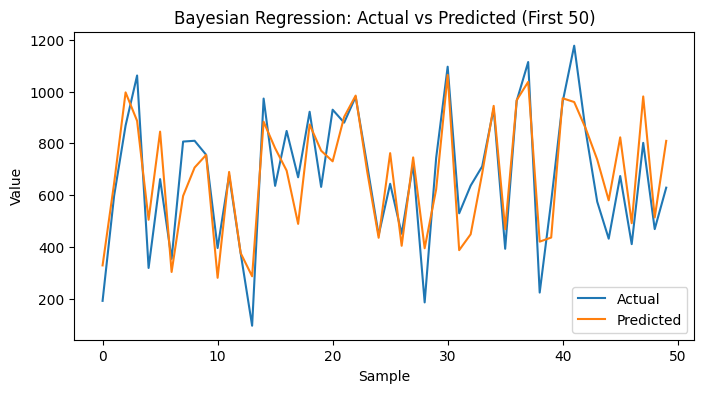

In [21]:
bayes = BayesianRidge()
bayes.fit(X_train, y_train)
y_pred_bayes = bayes.predict(X_test)
mse_bayes = mean_squared_error(y_test, y_pred_bayes)

print('Bayesian Linear Regression MSE:', mse_bayes)
print('First 5 predictions:', y_pred_bayes[:5])

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_bayes)
plt.title('Bayesian Regression: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred_bayes[:50], label='Predicted')
plt.title('Bayesian Regression: Actual vs Predicted (First 50)')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.legend()
plt.show()

## Final Comparison

In [22]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Polynomial Regression',
        'Stepwise Regression',
        'Decision Tree Regression',
        'Random Forest Regression',
        'Support Vector Regression',
        'Ridge Regression',
        'Lasso Regression',
        'ElasticNet Regression',
        'Bayesian Linear Regression'
    ],
    'MSE': [
        mse_lr, mse_poly, mse_step, mse_dt, mse_rf,
        mse_svr, mse_ridge, mse_lasso, mse_elastic, mse_bayes
    ]
})

results = results.sort_values('MSE')
print(results)

                        Model           MSE
2         Stepwise Regression  16187.328129
9  Bayesian Linear Regression  16249.342646
8       ElasticNet Regression  16252.506628
7            Lasso Regression  16256.564101
6            Ridge Regression  16260.031885
0           Linear Regression  16260.049658
1       Polynomial Regression  17093.662964
4    Random Forest Regression  18288.894826
3    Decision Tree Regression  34938.290000
5   Support Vector Regression  69872.163059


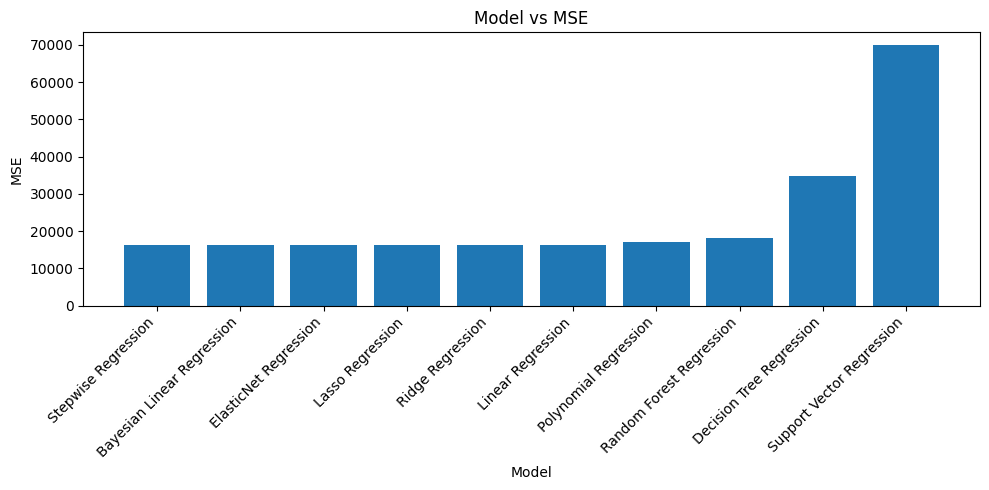

In [23]:
# Basic bar chart for comparison
plt.figure(figsize=(10,5))
plt.bar(results['Model'], results['MSE'])
plt.xticks(rotation=45, ha='right')
plt.title('Model vs MSE')
plt.xlabel('Model')
plt.ylabel('MSE')
plt.tight_layout()
plt.show()

## Final Output

In [24]:
best_row = results.iloc[0]
print('Best model is:', best_row['Model'])
print('Best MSE is:', best_row['MSE'])

Best model is: Stepwise Regression
Best MSE is: 16187.328128724914


### Observation
- I trained 10 regression models on the cleaned numerical data.
- I compared all models using Mean Squared Error (MSE).
- The model with the smallest MSE is the best model for this dataset in this notebook.